In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Download all of the data from MA E2C
import urllib
import os.path
import json

def download_e2c_dataset(dataset_code, file):
    meta_file = file + ".meta"

    if not os.path.isfile(file):
        req = urllib.request.Request(
            f"https://educationtocareer.data.mass.gov/api/v3/views/{dataset_code}/export.csv?accessType=DOWNLOAD",
            # Specify that we wouldn't like commas inside the numbers -- i.e. 1000 instead of 1,000.
            # Also, use "." as the decimal separator (maybe important for internationalization?)
            data=b'{"serializationOptions":{"defaultGroupSeparator":"","defaultDecimalSeparator":"."}}',
            method="POST",
            headers={
                "Accept": "text/csv",
                "Content-Type": "application/json",
                "X-App-Token": "U29jcmF0YS0td2VraWNrYXNz0"
            }
        )


        with open(meta_file, "wb") as meta_file_w:
            with urllib.request.urlopen(f"https://educationtocareer.data.mass.gov/api/views/{dataset_code}.json") as meta_req:
                meta_file_w.write(meta_req.read())
                meta_file_w.flush()

        with urllib.request.urlopen(req) as resp:
            if resp.status != 200:
                raise Exception("Couldn't load dataset")
            data = resp.read()
            with open(file, "wb") as file_w:
                file_w.write(data)
                file_w.flush()

    metadata = None 
    with open(meta_file) as meta_file_r:
        metadata = json.load(meta_file_r)

    df = pd.read_csv(file)

    for col in metadata["columns"]:
        colname = col["name"]
        fmt = col["format"].get("precisionStyle", col["dataTypeName"])
        # print(fmt)
        # print(df[colname].dtype == "str")
        
        # if df[colname].dtype == object:
        #     print(type(df[colname].dtype)) # this doesnt get printed

        if fmt == "percentage":
            df[colname] = pd.to_numeric(df[colname].str.replace("%", "")) / 100.0
        elif fmt == "number":
            df[colname] = pd.to_numeric(df[colname].str.replace(",", "") if df[colname].dtype == object or df[colname].dtype == "str" else df[colname])
        elif fmt == "currency":
            df[colname] = pd.to_numeric(df[colname].str.replace(",", "").str.replace("$", "") if df[colname].dtype == object or df[colname].dtype == "str" else df[colname])

    return df

# stu_eventual_earnings = download_e2c_dataset("9vfm-6vxq", "Average-Earnings-of-High-School-Graduates.csv")
# staffing = download_e2c_dataset("77fu-a6h8", "Elementary-and-Secondary-Teachers-by-Grade-and-Subject.csv")
# expenditures_district_detailed = download_e2c_dataset("cnfs-edqq", "District-Expenditures-by-Function-Code.csv")
# TODO: look for some subjective data from students? E2C has VOCAL, but only aggregated by state.

In [37]:
arts = download_e2c_dataset("w3f3-phkq", "Arts_Course_Taking_20260419.csv")
arts.columns = arts.columns.str.upper()
arts.head()

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,ART_SUBJ,STU_GRP,TOT_STU_CNT,ALL_GRDS_CNT,...,G08_CNT,G08_PCT,G09_CNT,G09_PCT,G10_CNT,G10_PCT,G11_CNT,G11_PCT,G12_CNT,G12_PCT
0,2025,0,State,0,State,State,All Subjects,All Students,885779.0,723263.0,...,62655.0,0.909,40643.0,0.558,37056.0,0.515,33566.0,0.471,36086.0,0.502
1,2025,0,State,0,State,State,Dance,All Students,885779.0,16206.0,...,799.0,0.012,892.0,0.012,858.0,0.012,823.0,0.012,729.0,0.010
2,2025,0,State,0,State,State,Media,All Students,885779.0,70777.0,...,6811.0,0.099,9625.0,0.132,8324.0,0.116,7677.0,0.108,9995.0,0.139
3,2025,0,State,0,State,State,Music,All Students,885779.0,560415.0,...,44451.0,0.645,13795.0,0.189,11016.0,0.153,10178.0,0.143,10933.0,0.152
4,2025,0,State,0,State,State,Theatre,All Students,885779.0,57564.0,...,10136.0,0.147,3203.0,0.044,2422.0,0.034,2189.0,0.031,2785.0,0.039


In [38]:
arts.where(arts["SY"] == 2025).dropna()

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,ART_SUBJ,STU_GRP,TOT_STU_CNT,ALL_GRDS_CNT,...,G08_CNT,G08_PCT,G09_CNT,G09_PCT,G10_CNT,G10_PCT,G11_CNT,G11_PCT,G12_CNT,G12_PCT
0,2025.0,0.0,State,0.0,State,State,All Subjects,All Students,885779.0,723263.0,...,62655.0,0.909,40643.0,0.558,37056.0,0.515,33566.0,0.471,36086.0,0.502
1,2025.0,0.0,State,0.0,State,State,Dance,All Students,885779.0,16206.0,...,799.0,0.012,892.0,0.012,858.0,0.012,823.0,0.012,729.0,0.010
2,2025.0,0.0,State,0.0,State,State,Media,All Students,885779.0,70777.0,...,6811.0,0.099,9625.0,0.132,8324.0,0.116,7677.0,0.108,9995.0,0.139
3,2025.0,0.0,State,0.0,State,State,Music,All Students,885779.0,560415.0,...,44451.0,0.645,13795.0,0.189,11016.0,0.153,10178.0,0.143,10933.0,0.152
4,2025.0,0.0,State,0.0,State,State,Theatre,All Students,885779.0,57564.0,...,10136.0,0.147,3203.0,0.044,2422.0,0.034,2189.0,0.031,2785.0,0.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161867,2025.0,3480000.0,Worcester,3480000.0,Worcester,District,Dance,Male,12477.0,51.0,...,26.0,0.029,0.0,0.000,1.0,0.001,1.0,0.001,1.0,0.001
161868,2025.0,3480000.0,Worcester,3480000.0,Worcester,District,Media,Male,12477.0,367.0,...,4.0,0.004,51.0,0.049,54.0,0.052,72.0,0.077,106.0,0.107
161869,2025.0,3480000.0,Worcester,3480000.0,Worcester,District,Music,Male,12477.0,8171.0,...,523.0,0.584,197.0,0.188,174.0,0.168,218.0,0.232,188.0,0.190
161870,2025.0,3480000.0,Worcester,3480000.0,Worcester,District,Theatre,Male,12477.0,365.0,...,83.0,0.093,29.0,0.028,50.0,0.048,42.0,0.045,48.0,0.048


In [39]:
ap_p = download_e2c_dataset("37cp-pad8", "Advanced_Placement_(AP)_Participation_20260419.csv")

ap_p.head()

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,STU_GRP,SUBJ_CAT,SUBJ,TEST_TAKERS_CNT,TESTS_TAKEN_CNT,ONE_TEST_CNT,TWO_TEST_CNT,THREE_TEST_CNT,FOUR_TEST_CNT,FIVE_PLUS_TEST_CNT
0,2025,0,State,0,State,State,All Students,All Subjects,All Subjects,65211,131220.0,28603.0,17892.0,11077.0,5255.0,2384.0
1,2025,0,State,0,State,State,American Indian or Alaska Native,All Subjects,All Subjects,98,187.0,48.0,25.0,15.0,6.0,4.0
2,2025,0,State,0,State,State,Asian,All Subjects,All Subjects,9453,23653.0,2873.0,2315.0,2056.0,1346.0,863.0
3,2025,0,State,0,State,State,Black or African American,All Subjects,All Subjects,4840,8612.0,2531.0,1314.0,648.0,253.0,94.0
4,2025,0,State,0,State,State,Hispanic or Latino,All Subjects,All Subjects,9314,16198.0,5094.0,2362.0,1240.0,468.0,150.0


In [40]:
sat = download_e2c_dataset("wihy-jkek", "SAT_Performance_20260419.csv")


In [41]:
sat.head()

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,STU_GRP,TAKEN_CNT,READ_SCORE,WRITE_SCORE,READ_WRITE_SCORE,MATH_SCORE
0,2025,0,State,0,State,State,All Students,49998,NaN,NaN,571.0,556.0
1,2025,0,State,0,State,State,American Indian or Alaska Native,80,NaN,NaN,537.0,526.0
2,2025,0,State,0,State,State,Asian,7023,NaN,NaN,620.0,641.0
3,2025,0,State,0,State,State,Black or African American,4524,NaN,NaN,493.0,475.0
4,2025,0,State,0,State,State,Hispanic or Latino,7723,NaN,NaN,488.0,470.0


In [42]:
sat["READ_SCORE"].value_counts()

READ_SCORE
498.0    331
495.0    315
501.0    313
503.0    311
497.0    304
        ... 
258.0      1
643.0      1
257.0      1
262.0      1
631.0      1
Name: count, Length: 425, dtype: int64

In [43]:
data = {"DIST_CODE": [],
        "STU_GRP": [],
        "ALL_GRADES_CNT": [],
        "READ_WRITE_SCORE": [],
        "MATH_SCORE": []}



In [63]:
t_sat = sat.where(sat["SY"] == 2025).where(sat["STU_GRP"] == "All Students").drop(columns=["READ_SCORE", "WRITE_SCORE"]).dropna()
t_arts = arts.where(arts["STU_GRP"] == "All Students").where(arts["ART_SUBJ"] == "All Subjects").dropna()

In [45]:
# total_arts.groupby(["ORG_CODE"]).apply(lambda x: x)
t_satf = t_sat.filter(["ORG_CODE", "TAKEN_CNT", "READ_WRITE_SCORE", "MATH_SCORE"])
t_artsf = t_arts.drop(columns=["SY", "DIST_CODE", "ART_SUBJ", "STU_GRP"]).dropna()
t_satf

,ORG_CODE,TAKEN_CNT,READ_WRITE_SCORE,MATH_SCORE
0,0.0,49998.0,571.0,556.0
261,4450000.0,49.0,544.0,536.0
271,4450105.0,49.0,544.0,536.0
281,10000.0,79.0,545.0,506.0
293,10505.0,79.0,545.0,506.0
...,...,...,...,...
7524,3480515.0,46.0,499.0,490.0
7535,3480520.0,137.0,570.0,556.0
7547,3480285.0,10.0,557.0,532.0
7556,3480000.0,455.0,552.0,536.0


In [46]:
df = t_artsf.drop(columns=[item for item in t_arts if item.endswith("CNT")]).merge(t_satf, on="ORG_CODE")

In [47]:
df.drop(columns=["DIST_NAME", "ORG_CODE", "ORG_NAME", "ORG_TYPE"]).corr()

,ALL_GRDS_PCT,GK_PCT,G01_PCT,G02_PCT,G03_PCT,G04_PCT,G05_PCT,G06_PCT,G07_PCT,G08_PCT,G09_PCT,G10_PCT,G11_PCT,G12_PCT,TAKEN_CNT,READ_WRITE_SCORE,MATH_SCORE
ALL_GRDS_PCT,1.000000,0.475930,0.593137,0.646848,0.687537,0.691124,0.686955,0.712187,0.200236,0.182037,0.320628,0.591083,0.580911,0.505302,-0.039188,0.085219,0.112702
GK_PCT,0.475930,1.000000,0.533118,0.459301,0.372166,0.373716,0.366000,0.408219,0.048770,-0.039566,-0.092913,0.054396,0.141814,0.130066,-0.007367,0.015978,0.021351
G01_PCT,0.593137,0.533118,1.000000,0.864463,0.701166,0.703715,0.693885,0.607055,-0.046704,-0.061293,-0.126245,0.125152,0.169830,0.157648,0.006511,0.093787,0.110056
G02_PCT,0.646848,0.459301,0.864463,1.000000,0.809829,0.812307,0.804200,0.716796,-0.017602,-0.040716,-0.118817,0.186374,0.216751,0.179083,0.005328,0.105294,0.132755
G03_PCT,0.687537,0.372166,0.701166,0.809829,1.000000,0.994894,0.985831,0.890279,-0.018338,-0.044684,-0.101577,0.265896,0.271778,0.274665,0.002728,0.148917,0.173726
G04_PCT,0.691124,0.373716,0.703715,0.812307,0.994894,1.000000,0.988410,0.885349,-0.021087,-0.040169,-0.100703,0.273584,0.264906,0.273012,0.004122,0.148295,0.173609
G05_PCT,0.686955,0.366000,0.693885,0.804200,0.985831,0.988410,1.000000,0.887889,-0.018740,-0.030498,-0.100352,0.270962,0.253469,0.258969,0.004540,0.145838,0.176058
G06_PCT,0.712187,0.408219,0.607055,0.716796,0.890279,0.885349,0.887889,1.000000,0.177953,0.099540,-0.048804,0.270199,0.224764,0.263382,-0.020741,0.213583,0.226982
G07_PCT,0.200236,0.048770,-0.046704,-0.017602,-0.018338,-0.021087,-0.018740,0.177953,1.000000,0.575188,0.051948,0.023581,-0.079005,-0.040433,-0.021623,0.072437,0.097819
G08_PCT,0.182037,-0.039566,-0.061293,-0.040716,-0.044684,-0.040169,-0.030498,0.099540,0.575188,1.000000,0.032395,0.040905,-0.059980,-0.055782,-0.009360,0.051154,0.072295


In [48]:
stu_eventual_earnings = download_e2c_dataset("9vfm-6vxq", "Average-Earnings-of-High-School-Graduates.csv")
staffing = download_e2c_dataset("77fu-a6h8", "Elementary-and-Secondary-Teachers-by-Grade-and-Subject.csv")
expenditures_district_detailed = download_e2c_dataset("cnfs-edqq", "District-Expenditures-by-Function-Code.csv")
# TODO: look for some subjective data from students? E2C has VOCAL, but only aggregated by state.

/tmp/ipykernel_2590512/1648419833.py:41: DtypeWarning: Columns (0: DIST_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


In [49]:
expenditures_district_detailed.head()

,SY,DIST_CODE,DIST_NAME,FUNC_CAT_CODE,FUNC_CAT_DESC,FUNC_CODE,FUNC_DESC,IN_OUT_DIST,GEN_FUND,GRNTS_REVOLV,TOT_EXP,PER_PUPIL_EXP
0,2024,10000,Abington,ADMN,Administration,1110,School Committee,In-District,372,0,372,0
1,2024,10000,Abington,ADMN,Administration,1210,Superintendent,In-District,336051,0,336051,157
2,2024,10000,Abington,ADMN,Administration,1410,Business and Finance,In-District,337128,0,337128,157
3,2024,10000,Abington,ADMN,Administration,1420,Human Resources and Benefits,In-District,112741,0,112741,53
4,2024,10000,Abington,ADMN,Administration,1430,Legal Service for School Committee,In-District,11983,0,11983,6


In [50]:
hs_district_staffing = staffing[(staffing["ORG_TYPE"] == "District")].drop(
            ["PK2_CNT", "PK2_PCT", "GRD_3_5_CNT", "GRD_3_5_PCT", "GRD_6_8_CNT", "GRD_6_8_PCT"], axis=1
        )

# Take the ALL, which will naturally be the largest one.
summed = hs_district_staffing.groupby("DIST_CODE", sort=False)["FTE_CNT"].transform("max")

for col in hs_district_staffing.columns:
    if col.endswith("_PCT"):
        hs_district_staffing[col] = hs_district_staffing[col.replace("_PCT", "_CNT")] / summed
 

# Remove the ALL pre-accumulated rows, as well as rows which represent subjects not served in the district (as shown by a FTE_COUNT of 0)
hs_district_staffing = hs_district_staffing[(hs_district_staffing["SUBJ"] != "All") & (hs_district_staffing["FTE_CNT"] > 0)]

hs_district_staffing.head()

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,SUBJ,GRD_9_12_CNT,GRD_9_12_PCT,MULTI_GRD_CNT,MULTI_GRD_PCT,ALL_GRD_CNT,ALL_GRD_PCT,FTE_CNT
45,2026,10000,Abington,10000,Abington,District,Arts,2.8,0.017241,0.0,0.0,0.0,0.0,9.7
46,2026,10000,Abington,10000,Abington,District,Business and Marketing,1.0,0.006158,0.0,0.0,0.0,0.0,1.0
59,2026,10000,Abington,10000,Abington,District,Civics/Government,0.4,0.002463,0.0,0.0,0.0,0.0,0.4
61,2026,10000,Abington,10000,Abington,District,Computer and Information Sciences,0.5,0.003079,0.0,0.0,0.0,0.0,1.5
62,2026,10000,Abington,10000,Abington,District,Core-All Subjects,0.0,0.000000,0.0,0.0,0.0,0.0,6.0


In [51]:


# Assign the year applicable to 3 years before their graduation: the first year of high school.
# We want to see how the investment affected their eventual success, and this will match years
# so that earnings data is grouped with the spending data that influenced it.
stu_eventual_earnings["SY"] = stu_eventual_earnings["HS_GRAD_YEAR"] - 3.0

stu_earnings_gendered = stu_eventual_earnings[(stu_eventual_earnings["DIST_CODE"] != 0) & # Exclude the state
                                              ((stu_eventual_earnings["STU_GRP"] == "Female") 
                                              | (stu_eventual_earnings["STU_GRP"] == "Male") 
                                              | (stu_eventual_earnings["STU_GRP"] == "All Students"))
                                              ]

all_merged_stats = pd.merge(stu_earnings_gendered, hs_district_staffing.drop(["DIST_NAME"], axis=1),
                                                            on=["SY", "DIST_CODE"],
                                                            how="inner", suffixes=["_earnings", "_staffing"]
                                                        )

all_merged_stats.head(n=10)

,HS_GRAD_YEAR,DIST_CODE,DIST_NAME,EARNINGS_YEAR,STU_GRP,GRAD_CNT,EMP_CNT,AVG_EARNINGS,SY,ORG_CODE,ORG_NAME,ORG_TYPE,SUBJ,GRD_9_12_CNT,GRD_9_12_PCT,MULTI_GRD_CNT,MULTI_GRD_PCT,ALL_GRD_CNT,ALL_GRD_PCT,FTE_CNT
0,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Arts,1.7,0.003376,9.5,0.018864,0.0,0.0,15.7
1,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Business and Marketing,0.2,0.000397,0.4,0.000794,0.0,0.0,0.6
2,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Civics/Government,0.7,0.001390,0.0,0.000000,0.0,0.0,0.7
3,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Computer and Information Sciences,0.6,0.001191,0.4,0.000794,0.0,0.0,1.0
4,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Core-All Subjects,3.7,0.007347,13.9,0.027601,0.0,0.0,152.9
5,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Engineering and Technology,0.0,0.000000,0.6,0.001191,0.0,0.0,3.0
6,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,English/Language Arts,12.3,0.024424,4.1,0.008141,0.0,0.0,25.8
7,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Foreign Language,7.5,0.014893,0.0,0.000000,0.0,0.0,10.9
8,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,History,7.1,0.014098,0.4,0.000794,0.0,0.0,7.5
9,2011,100000,Arlington,2012,Female,151,7.0,9544.0,2008.0,100000,Arlington,District,Hospitality and Tourism,1.2,0.002383,0.0,0.000000,0.0,0.0,1.2


<Axes: xlabel='GRD_9_12_PCT', ylabel='AVG_EARNINGS'>

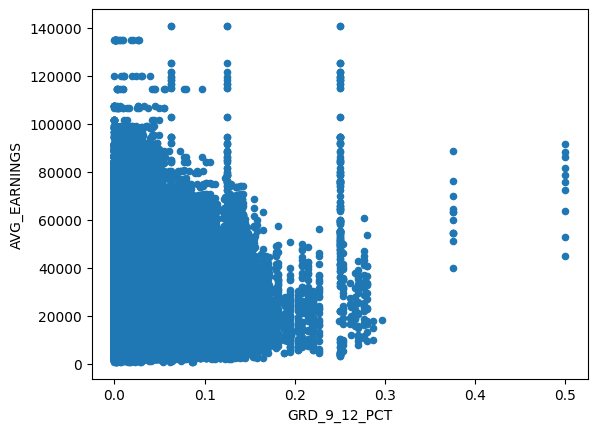

In [52]:
all_merged_stats.plot.scatter(x="GRD_9_12_PCT",  y="AVG_EARNINGS")

In [64]:
t_arts.groupby("SY").apply(lambda x: x)

DIST_CODE                                     DIST_NAME  \
SY                                                                        
2018.0 616            0.0                                         State   
       1198752  4450000.0  Abby Kelley Foster Charter Public (District)   
       1198836  4450000.0  Abby Kelley Foster Charter Public (District)   
       1198920    10000.0                                      Abington   
       1199484  6000000.0                              Acton-Boxborough   
...                   ...                                           ...   
2025.0 156760   3430000.0                                    Winchendon   
       157288   3440000.0                                    Winchester   
       157594   3460000.0                                      Winthrop   
       158548   3470000.0                                        Woburn   
       161788   3480000.0                                     Worcester   

                 ORG_CODE                                      ORG_NAME  \
SY                                                                        
2018.0 616            0.0                                         State   
       1198752  4450000.0  Abby Kelley Foster Charter Public (District)   
       1198836  4450105.0      Abby Kelley Foster Charter Public School   
       1198920    10000.0                                      Abington   
       1199484  6000000.0                              Acton-Boxborough   
...                   ...                                           ...   
2025.0 156760   3430000.0                                    Winchendon   
       157288   3440000.0                                    Winchester   
       157594   3460000.0                                      Winthrop   
       158548   3470000.0                                        Woburn   
       161788   3480000.0                                     Worcester   

                ORG_TYPE      ART_SUBJ       STU_GRP  TOT_STU_CNT  \
SY                                                                  
2018.0 616         State  All Subjects  All Students     928556.0   
       1198752  District  All Subjects  All Students       1420.0   
       1198836    School  All Subjects  All Students       1420.0   
       1198920  District  All Subjects  All Students       1979.0   
       1199484  District  All Subjects  All Students       5535.0   
...                  ...           ...           ...          ...   
2025.0 156760   District  All Subjects  All Students       1119.0   
       157288   District  All Subjects  All Students       4337.0   
       157594   District  All Subjects  All Students       1961.0   
       158548   District  All Subjects  All Students       4366.0   
       161788   District  All Subjects  All Students      24269.0   

                ALL_GRDS_CNT  ALL_GRDS_PCT  ...  G08_CNT  G08_PCT  G09_CNT  \
SY                                          ...                              
2018.0 616          740522.0         0.797  ...  65643.0    0.903  40154.0   
       1198752        1374.0         0.968  ...    119.0    1.000     99.0   
       1198836        1374.0         0.968  ...    119.0    1.000     99.0   
       1198920        1712.0         0.865  ...    169.0    0.994     78.0   
       1199484        4405.0         0.796  ...    464.0    0.961    286.0   
...                      ...           ...  ...      ...      ...      ...   
2025.0 156760         1055.0         0.943  ...     92.0    0.948     51.0   
       157288         3331.0         0.768  ...    342.0    0.986    230.0   
       157594         1673.0         0.853  ...    153.0    0.994    110.0   
       158548         3656.0         0.837  ...    339.0    0.983    161.0   
       161788        19564.0         0.806  ...   1660.0    0.944    813.0   

                G09_PCT  G10_CNT  G10_PCT  G11_CNT  G11_PCT  G12_CNT  G12_PCT  
SY                                                                     

In [69]:
mcas = pd.read_csv("../girls_inc/MCAS_Achievement_Results_20260420.csv")
mcas = download_e2c_dataset("i9w6-niyt" "MCAS_Achievement_Results.csv")

/tmp/ipykernel_2590512/2648937040.py:1: DtypeWarning: Columns (0: E_CNT, 1: M_CNT, 2: NM_CNT, 3: STU_PART_PCT) have mixed types. Specify dtype option on import or set low_memory=False.
  mcas = pd.read_csv("../girls_inc/MCAS_Achievement_Results_20260420.csv")


TypeError: download_e2c_dataset() missing 1 required positional argument: 'file'

In [68]:
mcas

,SY,DIST_CODE,DIST_NAME,ORG_CODE,ORG_NAME,ORG_TYPE,TEST_GRADE,SUBJECT_CODE,STU_GRP,M_PLUS_E_CNT,...,PM_PCT,NM_CNT,NM_PCT,STU_CNT,STU_PART_PCT,AVG_SCALED_SCORE,AVG_SGP,AVG_SGP_INCL,ACH_PERCENTILE,DISTRICT_AND_SCHOOL
0,2025,0,State,0,State,State,03,MATH,Black or African American,"1,550",...,41%,"2,143",34%,"6,250",99%,484.0,NaN,NaN,NaN,State
1,2025,0,State,0,State,State,03,ELA,English Learners,"1,115",...,46%,"5,113",44%,"11,526",99%,474.0,NaN,NaN,NaN,State
2,2025,0,State,0,State,State,03,MATH,English Learners,"1,873",...,41%,"4,965",43%,"11,573",100%,477.0,NaN,NaN,NaN,State
3,2025,0,State,0,State,State,03,ELA,All Students,"28,167",...,39%,"12,344",19%,"66,312",99%,494.0,NaN,NaN,NaN,State
4,2025,0,State,0,State,State,03,MATH,All Students,"28,870",...,36%,"13,774",21%,"66,361",99%,496.0,NaN,NaN,NaN,State
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066481,2017,3500000,Wrentham,3500000,Wrentham,Public School District,ALL (03-08),MATH,Students without Disabilities,401,...,21%,3,1%,513,NaN,511.0,54.0,362,NaN,Wrentham (District)
2066482,2017,3500000,Wrentham,3500000,Wrentham,Public School District,ALL (03-08),ELA,Title I,5,...,76%,0,0%,21,NaN,492.0,NaN,NaN,NaN,Wrentham (District)
2066483,2017,3500000,Wrentham,3500000,Wrentham,Public School District,ALL (03-08),MATH,Title I,10,...,52%,0,0%,21,NaN,498.0,NaN,NaN,NaN,Wrentham (District)
2066484,2017,3500000,Wrentham,3500000,Wrentham,Public School District,ALL (03-08),ELA,White,368,...,29%,16,3%,540,NaN,510.0,65.0,386,NaN,Wrentham (District)


In [84]:
mcasf = mcas.filter(["ORG_CODE", "STU_GRP", "TEST_GRADE", "AVG_SCALED_SCORE"])

In [112]:
arts_melt["variable"] = arts_melt["variable"].replace("G", "", regex=True).replace("_PCT", "", regex=True).replace("K", "0", regex=True)

In [113]:
arts_melt.merge(mcasf, on="ORG_CODE").drop(columns=["DIST_NAME", "ORG_NAME", "ORG_TYPE", "STU_GRP", "TEST_GRADE"]).corr()

,ORG_CODE,TOT_STU_CNT,ALL_GRDS_CNT,ALL_GRDS_PCT,variable,value,AVG_SCALED_SCORE
ORG_CODE,1.000000e+00,-6.195971e-02,-6.304126e-02,-2.723460e-01,1.454918e-14,-0.036790,-7.544134e-02
TOT_STU_CNT,-6.195971e-02,1.000000e+00,9.999834e-01,-4.751616e-02,7.148262e-15,-0.011702,-2.737341e-02
ALL_GRDS_CNT,-6.304126e-02,9.999834e-01,1.000000e+00,-4.430437e-02,2.860694e-15,-0.010754,-2.666977e-02
ALL_GRDS_PCT,-2.723460e-01,-4.751616e-02,-4.430437e-02,1.000000e+00,2.046918e-13,0.309040,8.932498e-02
variable,1.454918e-14,7.148262e-15,2.860694e-15,2.046918e-13,1.000000e+00,-0.635975,-1.835057e-13
value,-3.678970e-02,-1.170230e-02,-1.075412e-02,3.090403e-01,-6.359747e-01,1.000000,2.587637e-02
AVG_SCALED_SCORE,-7.544134e-02,-2.737341e-02,-2.666977e-02,8.932498e-02,-1.835057e-13,0.025876,1.000000e+00


In [103]:
arts_melt = t_artsf.drop(columns=[item for item in t_artsf if item.endswith("CNT") and item.startswith("G")]).melt(id_vars=["DIST_NAME", "ORG_CODE", "ORG_NAME", "ORG_TYPE", "TOT_STU_CNT", "ALL_GRDS_CNT", "ALL_GRDS_PCT"])